# K-means clustering

C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows wit

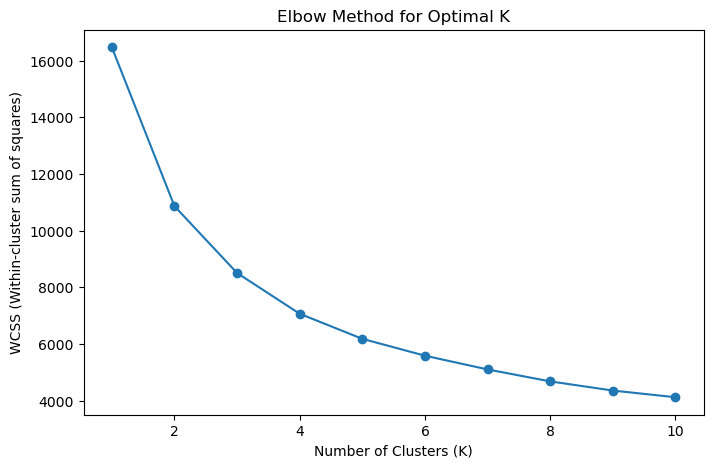

C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


Clustered data saved to clustered_wind_data_1998_2024_k4.csv


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
file_path = "final_combined_daily_wind_data_1998_2024.csv"
df = pd.read_csv(file_path, parse_dates=["Date"])

# Filter data for the given date range
start_date = "1998-06-01"
end_date = "2024-08-31"
df_filtered = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)]

# Select only relevant columns for clustering
features = ["U_mor", "V_mor", "U_aft", "V_aft", "Cos_Theta", "Sin_Theta", "R"]
X = df_filtered[features]

# Handle missing values (choose one approach)
df_filtered.dropna(inplace=True)  # Drops rows with NaN
# df_filtered.fillna(df_filtered.mean(), inplace=True)  # Alternative: Fill NaN with column mean

# Normalize the data (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filtered[features])

# Determine the optimal number of clusters using the Elbow Method
wcss = []  # Within-cluster sum of squares
K_range = range(1, 11)  # Testing K from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # Inertia is the sum of squared distances to cluster center

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-cluster sum of squares)")
plt.title("Elbow Method for Optimal K")
plt.show()

# Choose optimal K (e.g., based on elbow method, let's assume K=3)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_filtered["Cluster"] = kmeans.fit_predict(X_scaled)

# Save clustered data
output_file = "clustered_wind_data_1998_2024_k4.csv"
df_filtered.to_csv(output_file, index=False)

print(f"Clustered data saved to {output_file}")
